# Malicious Web Request Detection

This notebook presents a leakage-aware academic pipeline for binary classification of **benign** versus **malicious** web requests.

Key design commitments:

- keep conservative request cleaning
- remove **exact duplicates**
- remove **normalized duplicates**
- keep **group-aware splitting by `source_file`**
- prevent obvious **train/test overlap**
- avoid fitting text vectorizers on the full dataset before splitting
- provide stronger evaluation, visual analysis, threshold analysis, cross-validation, and exportable artifacts


## Project Overview

Build a practical machine learning benchmark for malicious web request detection while minimizing inflated performance caused by dataset repetition, source contamination, or accidental leakage.



## Imports & Setup

The next cell installs the required packages when needed, sets deterministic seeds, prepares output folders, and defines project-wide configuration values.

In [ ]:
%%capture
!pip -q install xgboost joblib

In [ ]:
import gc
import io
import os
import re
import json
import math
import time
import glob
import shutil
import zipfile
import pickle
import random
import pathlib
import warnings
from collections import Counter
from datetime import datetime, timezone

import joblib
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.special import expit

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from xgboost import XGBClassifier
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 3
FAST_MODE = True

LINEAR_MAX_FEATURES = 2500 if FAST_MODE else 8000
TREE_TEXT_MAX_FEATURES = 1500 if FAST_MODE else 5000
SVD_COMPONENTS = 80 if FAST_MODE else 200

LEGITIMATE_URL = "https://downloads.openappsec.io/waf-comparison-project/legitimate.zip"
MALICIOUS_URL = "https://downloads.openappsec.io/waf-comparison-project/malicious.zip"

PROJECT_ROOT = pathlib.Path.cwd() / "malicious_web_request_final_project"
DATA_ROOT = PROJECT_ROOT / "data"
DOWNLOAD_DIR = DATA_ROOT / "downloads"
EXTRACT_DIR = DATA_ROOT / "extracted"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for p in [PROJECT_ROOT, DATA_ROOT, DOWNLOAD_DIR, EXTRACT_DIR, OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Project root:", PROJECT_ROOT)
print("Figures folder:", FIG_DIR)
print("Tables folder:", TABLE_DIR)
print("Models folder:", MODEL_DIR)

Project root: /content/malicious_web_request_final_project
Figures folder: /content/malicious_web_request_final_project/outputs/figures
Tables folder: /content/malicious_web_request_final_project/outputs/tables
Models folder: /content/malicious_web_request_final_project/outputs/models


## Data Loading

The dataset is downloaded directly from the public source, saved locally, and extracted into the runtime. The loading code is defensive and raises explicit errors if a file is empty, broken, or missing after extraction.

In [ ]:
def timed_call(fn, *args, **kwargs):
    start = time.perf_counter()
    result = fn(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed

def download_file(url: str, output_path: pathlib.Path, chunk_size: int = 1024 * 1024):
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    with open(output_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)

    if not output_path.exists() or output_path.stat().st_size == 0:
        raise RuntimeError(f"Downloaded file is empty: {output_path}")

    return output_path

def extract_zip(zip_path: pathlib.Path, destination: pathlib.Path):
    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(destination)
    except zipfile.BadZipFile as e:
        raise RuntimeError(f"Downloaded file is not a valid ZIP archive: {zip_path}") from e

    extracted_files = [p for p in destination.rglob("*") if p.is_file()]
    if not extracted_files:
        raise RuntimeError(f"No files were extracted from: {zip_path}")

    return destination

def download_and_extract(label_name: str, url: str):
    zip_path = DOWNLOAD_DIR / f"{label_name.lower()}.zip"
    extract_path = EXTRACT_DIR / label_name

    _, download_seconds = timed_call(download_file, url, zip_path)
    _, extract_seconds = timed_call(extract_zip, zip_path, extract_path)

    return {
        "label_name": label_name,
        "zip_path": str(zip_path),
        "extract_path": str(extract_path),
        "download_seconds": download_seconds,
        "extract_seconds": extract_seconds,
        "zip_size_mb": round(zip_path.stat().st_size / (1024 ** 2), 3)
    }

download_start = time.perf_counter()

legit_meta = download_and_extract("Legitimate", LEGITIMATE_URL)
mal_meta = download_and_extract("Malicious", MALICIOUS_URL)

download_total_seconds = time.perf_counter() - download_start

download_df = pd.DataFrame([legit_meta, mal_meta])
display(download_df)

print(f"Total acquisition time: {download_total_seconds:.2f} seconds")

,label_name,zip_path,extract_path,download_seconds,extract_seconds,zip_size_mb
0,Legitimate,/content/malicious_web_request_final_project/d...,/content/malicious_web_request_final_project/d...,37.469747,59.447686,1148.208
1,Malicious,/content/malicious_web_request_final_project/d...,/content/malicious_web_request_final_project/d...,0.996458,0.047394,0.432


Total acquisition time: 97.96 seconds


## Initial File Inspection

This is a quick structural check before parsing. It helps verify that the archives were extracted correctly and that the dataset still looks consistent with expectations.

In [ ]:
def summarize_directory(root: pathlib.Path, max_files: int = 20):
    all_files = [p for p in root.rglob("*") if p.is_file()]
    return {
        "root": str(root),
        "total_files": len(all_files),
        "json_files": sum(1 for p in all_files if p.suffix.lower() == ".json"),
        "sample_files": [str(p.relative_to(root)) for p in all_files[:max_files]]
    }

def read_json_preview(root: pathlib.Path, n: int = 3):
    json_files = sorted(root.rglob("*.json"))[:n]
    previews = []
    for path in json_files:
        try:
            with open(path, "r", encoding="utf-8") as f:
                obj = json.load(f)
            previews.append({
                "file": str(path.relative_to(root)),
                "python_type": type(obj).__name__,
                "preview": str(obj)[:700]
            })
        except Exception as e:
            previews.append({
                "file": str(path.relative_to(root)),
                "python_type": "ERROR",
                "preview": f"{type(e).__name__}: {e}"
            })
    return pd.DataFrame(previews)

legit_root = pathlib.Path(legit_meta["extract_path"])
mal_root = pathlib.Path(mal_meta["extract_path"])

display(pd.DataFrame([summarize_directory(legit_root), summarize_directory(mal_root)]))
display(read_json_preview(legit_root, n=3))
display(read_json_preview(mal_root, n=3))

,root,total_files,json_files,sample_files
0,/content/malicious_web_request_final_project/d...,692,692,"[Legitimate/browsing_crocs.json, Legitimate/br..."
1,/content/malicious_web_request_final_project/d...,7,7,"[Malicious/xxe.json, Malicious/xss.json, Malic..."


,file,python_type,preview
0,Legitimate/browsing_2024_1800flowers_al.json,list,"[{'method': 'GET', 'url': '/', 'headers': {'ho..."
1,Legitimate/browsing_2024_4shared.json,list,"[{'method': 'GET', 'url': '/chrome-variations/..."
2,Legitimate/browsing_2024_aa_ni.json,list,"[{'method': 'POST', 'url': '/akam/13/pixel_47c..."


,file,python_type,preview
0,Malicious/cmdexe.json,list,"[{'method': 'GET', 'url': '/?p=%24aaaaaa/bin%2..."
1,Malicious/log4shell.json,list,"[{'method': 'GET', 'url': '/?p=%24%7B%24%7B%3A..."
2,Malicious/shellshock.json,list,"[{'method': 'GET', 'url': '/?p=%28%29%20%7B%20..."


## Data Cleaning & Deduplication

The parsing and cleaning logic below preserves the conservative philosophy of the original notebook.

### Preserved rules
- keep suspicious punctuation and encoded patterns
- strip only null-like noise and redundant whitespace
- remove **exact duplicates**
- remove **normalized duplicates**
- keep `source_file` for group-aware splitting

### Important note
Deduplication is done **before evaluation**, not after the split, to avoid artificial inflation from repeated requests.

In [ ]:
REQUEST_FIELD_TOKENS = [
    "request", "http_request", "request_line", "line",
    "uri", "url", "path", "query", "payload", "body", "header",
    "headers", "full_request", "raw_request"
]

def flatten_json_record(obj, prefix=""):
    items = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            new_key = f"{prefix}.{k}" if prefix else str(k)
            items.update(flatten_json_record(v, new_key))
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            new_key = f"{prefix}[{i}]"
            items.update(flatten_json_record(v, new_key))
    else:
        items[prefix] = obj
    return items

def pick_first_request_like_value(flat_record: dict):
    for k, v in flat_record.items():
        lk = str(k).lower()
        if any(token in lk for token in REQUEST_FIELD_TOKENS):
            if isinstance(v, str) and len(v.strip()) > 0:
                return v

    scored_candidates = []
    for _, v in flat_record.items():
        if isinstance(v, str):
            score = 0
            lv = v.lower()
            if "/" in v:
                score += 1
            if "http" in lv or "get " in lv or "post " in lv or "?" in v:
                score += 2
            if any(sym in v for sym in ["<", ">", "'", '"', "%", "&", "=", "..", "\\"]):
                score += 1
            score += min(len(v) / 200.0, 2)
            scored_candidates.append((score, v))

    if scored_candidates:
        scored_candidates.sort(key=lambda x: x[0], reverse=True)
        return scored_candidates[0][1]

    return None

def collect_candidate_records(obj):
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for likely_key in ["requests", "data", "records", "items", "entries", "payloads", "samples"]:
            if likely_key in obj and isinstance(obj[likely_key], list):
                return obj[likely_key]
        return [obj]
    return [obj]

def clean_request_text(text: str) -> str:
    text = str(text)
    text = text.replace("\\x00", " ").replace("\\u0000", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_request_signature(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"%[0-9a-f]{2}", "%HEX", text)
    text = re.sub(r"0x[0-9a-f]+", "HEX", text)
    text = re.sub(r"[0-9]+", "0", text)
    text = re.sub(r"[a-f0-9]{24,}", "HASH", text)
    text = re.sub(r"([/?=&._\-])\1+", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def infer_attack_family(path: pathlib.Path, root: pathlib.Path):
    rel = str(path.relative_to(root)).replace("\\", "/").lower()
    parts = [p for p in rel.split("/") if p]
    if len(parts) >= 2:
        return parts[-2]
    if len(parts) == 1:
        return pathlib.Path(parts[0]).stem.lower()
    return "unknown"

def parse_archive_to_df(root: pathlib.Path, label: int, label_name: str):
    rows = []
    json_files = sorted(root.rglob("*.json"))

    for path in json_files:
        try:
            with open(path, "r", encoding="utf-8") as f:
                obj = json.load(f)
        except Exception:
            continue

        candidate_records = collect_candidate_records(obj)

        for rec in candidate_records:
            flat = flatten_json_record(rec) if isinstance(rec, (dict, list)) else {"value": rec}
            request_value = pick_first_request_like_value(flat)
            if request_value is None:
                continue

            cleaned = clean_request_text(request_value)
            if len(cleaned) < 3:
                continue

            rows.append({
                "raw_request": cleaned,
                "label": int(label),
                "label_name": label_name,
                "source_file": str(path.relative_to(root)),
                "attack_family": infer_attack_family(path, root)
            })

    return pd.DataFrame(rows)

legit_df_raw = parse_archive_to_df(legit_root, 0, "Benign")
mal_df_raw = parse_archive_to_df(mal_root, 1, "Malicious")

df_before_cleaning = pd.concat([legit_df_raw, mal_df_raw], axis=0, ignore_index=True)
df_before_cleaning["raw_request"] = df_before_cleaning["raw_request"].astype(str).map(clean_request_text)

df_after_cleaning = df_before_cleaning[df_before_cleaning["raw_request"].str.len() >= 3].copy()
df_after_cleaning["request_signature"] = df_after_cleaning["raw_request"].map(build_request_signature)

# Preserve the original logic:
# 1) remove exact duplicates
# 2) remove normalized duplicates inside each class
df = df_after_cleaning.drop_duplicates(subset=["raw_request"]).reset_index(drop=True)
df = df.drop_duplicates(subset=["label", "request_signature"]).reset_index(drop=True)

required_columns = {"raw_request", "label", "label_name", "source_file", "request_signature"}
missing_cols = required_columns - set(df.columns)
if missing_cols:
    raise RuntimeError(f"Missing required columns after parsing and cleaning: {missing_cols}")

if df["label"].nunique() != 2:
    raise RuntimeError("The parsed dataset does not contain exactly two classes.")

class_counts = df["label"].value_counts().to_dict()
if 0 not in class_counts or 1 not in class_counts:
    raise RuntimeError(f"Both classes are required, but observed counts were: {class_counts}")

dataset_stage_summary = pd.DataFrame([
    {
        "stage": "Before cleaning",
        "rows": len(df_before_cleaning),
        "benign": int((df_before_cleaning["label"] == 0).sum()),
        "malicious": int((df_before_cleaning["label"] == 1).sum()),
        "unique_raw_requests": int(df_before_cleaning["raw_request"].nunique())
    },
    {
        "stage": "After cleaning",
        "rows": len(df_after_cleaning),
        "benign": int((df_after_cleaning["label"] == 0).sum()),
        "malicious": int((df_after_cleaning["label"] == 1).sum()),
        "unique_raw_requests": int(df_after_cleaning["raw_request"].nunique())
    },
    {
        "stage": "After exact + normalized deduplication",
        "rows": len(df),
        "benign": int((df["label"] == 0).sum()),
        "malicious": int((df["label"] == 1).sum()),
        "unique_raw_requests": int(df["raw_request"].nunique())
    }
])

display(dataset_stage_summary)

signature_summary = pd.DataFrame({
    "metric": ["unique_raw_requests", "unique_signatures", "duplicate_reduction_ratio"],
    "value": [
        int(df["raw_request"].nunique()),
        int(df["request_signature"].nunique()),
        round(1 - (df["request_signature"].nunique() / max(df["raw_request"].nunique(), 1)), 4)
    ]
})
display(signature_summary)

display(df.sample(min(5, len(df)), random_state=RANDOM_STATE)[["label_name", "attack_family", "source_file", "raw_request"]])

,stage,rows,benign,malicious,unique_raw_requests
0,Before cleaning,1067084,1030122,36962,636243
1,After cleaning,1067084,1030122,36962,636243
2,After exact + normalized deduplication,460579,430392,30187,460579


,metric,value
0,unique_raw_requests,460579.0
1,unique_signatures,460579.0
2,duplicate_reduction_ratio,0.0


,label_name,attack_family,source_file,raw_request
349248,Benign,legitimate,Legitimate/browsing_best_buy.json,/~assets/bby/_com/shop/deals-on-pdp/dist/clien...
148341,Benign,legitimate,Legitimate/browsing_2024_ivory.json,/files/catalog/org/1603615684B84GF.jpg
286108,Benign,legitimate,Legitimate/browsing_2024_tobi_az.json,/product_images/md/1/brown-those-days-cutout-c...
356689,Benign,legitimate,Legitimate/browsing_dailymail.json,/sync?ssp=bidswitch&bidswitch_ssp_id=index
37226,Benign,legitimate,Legitimate/browsing_2024_bilibili.json,/x/v2/dm/wbi/web/seg.so?type=1&oid=351796095&p...


## Leakage Checks

This section verifies the two most important constraints:

1. `source_file` must not overlap between train and test.
2. exact request text must not overlap between train and test.

A remaining overlap in **normalized signatures** is reported as a warning rather than silently ignored, because it can still matter in discussion.

In [ ]:
groups = df["source_file"].astype(str)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(gss.split(df, y=df["label"], groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

X_train_df = train_df[["raw_request"]].copy()
X_test_df = test_df[["raw_request"]].copy()
y_train = train_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values
groups_train = train_df["source_file"].astype(str).values
groups_test = test_df["source_file"].astype(str).values

shared_source_files = set(train_df["source_file"]).intersection(set(test_df["source_file"]))
shared_raw_requests = set(train_df["raw_request"]).intersection(set(test_df["raw_request"]))
shared_signatures = set(train_df["request_signature"]).intersection(set(test_df["request_signature"]))

leakage_summary = pd.DataFrame({
    "check": [
        "shared_source_files",
        "shared_exact_requests",
        "shared_normalized_signatures"
    ],
    "count": [
        len(shared_source_files),
        len(shared_raw_requests),
        len(shared_signatures)
    ]
})

display(leakage_summary)

if len(shared_source_files) != 0:
    raise RuntimeError("Source-file leakage detected between train and test splits.")

if len(shared_raw_requests) != 0:
    raise RuntimeError("Exact duplicate requests are shared across train and test splits.")

if len(shared_signatures) > 0:
    print("Warning: normalized template overlap remains after source-aware splitting.")
    print("This is not automatically a bug, but it must be acknowledged when interpreting very high scores.")
else:
    print("No normalized-template overlap was detected in this run.")

split_summary = pd.DataFrame([
    {
        "partition": "Train",
        "rows": len(train_df),
        "benign": int((train_df["label"] == 0).sum()),
        "malicious": int((train_df["label"] == 1).sum()),
        "unique_source_files": int(train_df["source_file"].nunique())
    },
    {
        "partition": "Test",
        "rows": len(test_df),
        "benign": int((test_df["label"] == 0).sum()),
        "malicious": int((test_df["label"] == 1).sum()),
        "unique_source_files": int(test_df["source_file"].nunique())
    }
])
display(split_summary)

,check,count
0,shared_source_files,0
1,shared_exact_requests,0
2,shared_normalized_signatures,0


No normalized-template overlap was detected in this run.


,partition,rows,benign,malicious,unique_source_files
0,Train,376520,346737,29783,558
1,Test,84059,83655,404,140


## Exploratory Analysis

Before training, we examine class balance and request-length behavior across processing stages. This gives a more transparent view of whether the dataset is still large enough, still plausible, and still balanced enough for a meaningful experiment.

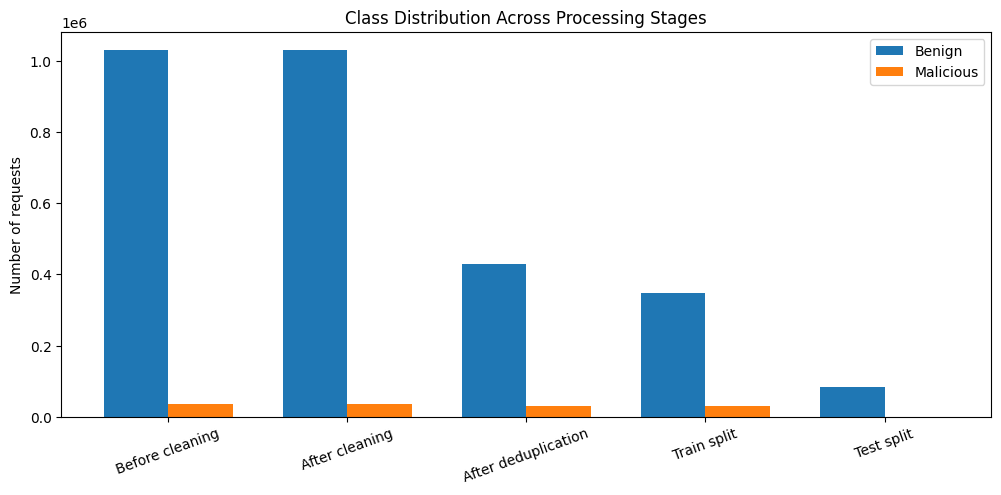

Saved figure: /content/malicious_web_request_final_project/outputs/figures/class_distribution.png


PosixPath('/content/malicious_web_request_final_project/outputs/figures/class_distribution.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
def save_current_figure(filename: str):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

# Class distribution across stages
distribution_plot_df = pd.DataFrame([
    {"stage": "Before cleaning", "class": "Benign", "count": int((df_before_cleaning["label"] == 0).sum())},
    {"stage": "Before cleaning", "class": "Malicious", "count": int((df_before_cleaning["label"] == 1).sum())},
    {"stage": "After cleaning", "class": "Benign", "count": int((df_after_cleaning["label"] == 0).sum())},
    {"stage": "After cleaning", "class": "Malicious", "count": int((df_after_cleaning["label"] == 1).sum())},
    {"stage": "After deduplication", "class": "Benign", "count": int((df["label"] == 0).sum())},
    {"stage": "After deduplication", "class": "Malicious", "count": int((df["label"] == 1).sum())},
    {"stage": "Train split", "class": "Benign", "count": int((train_df["label"] == 0).sum())},
    {"stage": "Train split", "class": "Malicious", "count": int((train_df["label"] == 1).sum())},
    {"stage": "Test split", "class": "Benign", "count": int((test_df["label"] == 0).sum())},
    {"stage": "Test split", "class": "Malicious", "count": int((test_df["label"] == 1).sum())},
])

stage_order = ["Before cleaning", "After cleaning", "After deduplication", "Train split", "Test split"]
x = np.arange(len(stage_order))
benign_counts = distribution_plot_df[distribution_plot_df["class"] == "Benign"].set_index("stage").loc[stage_order, "count"].values
mal_counts = distribution_plot_df[distribution_plot_df["class"] == "Malicious"].set_index("stage").loc[stage_order, "count"].values

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.36
ax.bar(x - width / 2, benign_counts, width=width, label="Benign")
ax.bar(x + width / 2, mal_counts, width=width, label="Malicious")
ax.set_xticks(x)
ax.set_xticklabels(stage_order, rotation=20)
ax.set_ylabel("Number of requests")
ax.set_title("Class Distribution Across Processing Stages")
ax.legend()
plt.show()
save_current_figure("class_distribution.png")

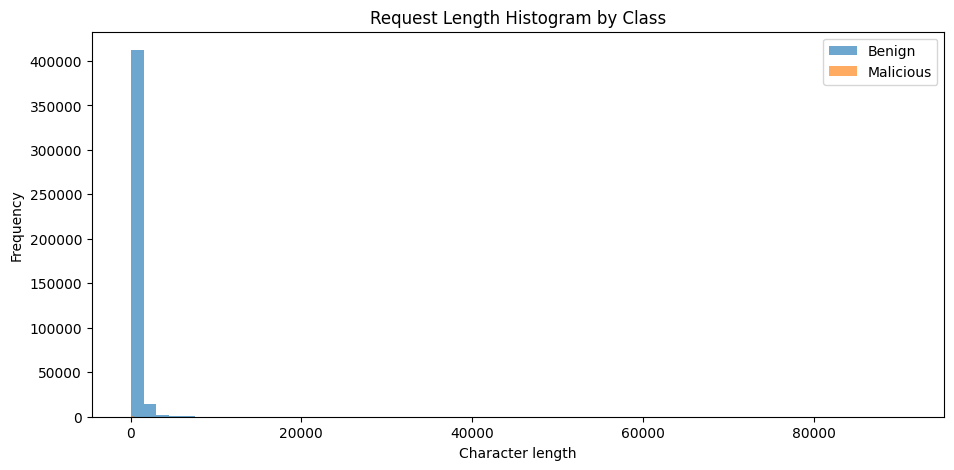

Saved figure: /content/malicious_web_request_final_project/outputs/figures/request_length_histogram.png


PosixPath('/content/malicious_web_request_final_project/outputs/figures/request_length_histogram.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
df["request_length"] = df["raw_request"].str.len()
train_df["request_length"] = train_df["raw_request"].str.len()
test_df["request_length"] = test_df["raw_request"].str.len()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df.loc[df["label"] == 0, "request_length"], bins=60, alpha=0.65, label="Benign")
ax.hist(df.loc[df["label"] == 1, "request_length"], bins=60, alpha=0.65, label="Malicious")
ax.set_title("Request Length Histogram by Class")
ax.set_xlabel("Character length")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()
save_current_figure("request_length_histogram.png")

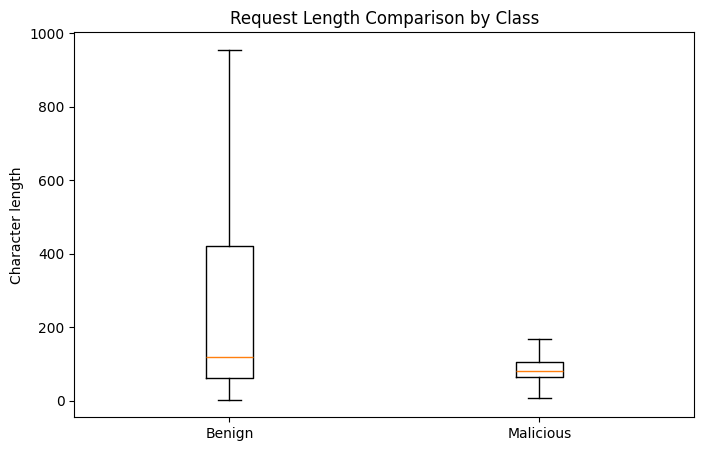

Saved figure: /content/malicious_web_request_final_project/outputs/figures/request_length_boxplot.png


,label_name,count,mean,median,std,min,max
0,Benign,430392,369.058110,119.0,695.063963,3,90792
1,Malicious,30187,94.634445,82.0,68.468368,9,3795


<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [
    df.loc[df["label"] == 0, "request_length"].values,
    df.loc[df["label"] == 1, "request_length"].values
]
ax.boxplot(data_to_plot, labels=["Benign", "Malicious"], showfliers=False)
ax.set_title("Request Length Comparison by Class")
ax.set_ylabel("Character length")
plt.show()
save_current_figure("request_length_boxplot.png")

request_length_summary = df.groupby("label_name")["request_length"].agg(["count", "mean", "median", "std", "min", "max"]).reset_index()
display(request_length_summary)

## Feature Engineering

The feature design combines **character-level TF-IDF** with lightweight structural features. The goal is to keep the representation expressive enough for malicious payload patterns without turning the notebook into a hand-written rule engine.

To make the final saved artifact reusable, the preprocessing logic is wrapped in sklearn-compatible transformers and pipelines.

In [ ]:
def shannon_entropy(text: str) -> float:
    if not text:
        return 0.0
    counts = np.array(list(Counter(text).values()), dtype=float)
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs + 1e-12)).sum())

class TextColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, column="raw_request"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X[self.column].fillna("").astype(str).values
        if isinstance(X, pd.Series):
            return X.fillna("").astype(str).values
        return pd.Series(X).fillna("").astype(str).values

class HandcraftedFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X).fillna("").astype(str)
        lower = s.str.lower()

        features = pd.DataFrame({
            "length": s.str.len(),
            "digit_count": s.str.count(r"\d"),
            "slash_count": s.str.count(r"/"),
            "backslash_count": s.str.count(r"\\"),
            "question_count": s.str.count(r"\?"),
            "ampersand_count": s.str.count(r"&"),
            "equals_count": s.str.count(r"="),
            "percent_count": s.str.count(r"%"),
            "dotdot_count": s.str.count(r"\.\."),
            "special_char_count": s.str.count(r"[^A-Za-z0-9\s]"),
            "space_count": s.str.count(r"\s"),
            "dash_count": s.str.count(r"-"),
            "underscore_count": s.str.count(r"_"),
            "colon_count": s.str.count(r":"),
            "semicolon_count": s.str.count(r";"),
            "open_paren_count": s.str.count(r"\("),
            "close_paren_count": s.str.count(r"\)"),
            "entropy": s.map(shannon_entropy),
            "percent_encoded_triplets": lower.str.count(r"%[0-9a-f]{2}"),
            "keyword_density": lower.str.count(r"(select|union|script|cmd|powershell|wget|curl|jndi|/etc/passwd|\.\.)"),
            "path_depth": s.str.count(r"/"),
            "query_parameter_count": s.str.count(r"=")
        })

        features["digit_ratio"] = features["digit_count"] / features["length"].clip(lower=1)
        features["special_char_ratio"] = features["special_char_count"] / features["length"].clip(lower=1)
        features["encoding_ratio"] = features["percent_count"] / features["length"].clip(lower=1)
        features["delimiter_ratio"] = (
            features["slash_count"]
            + features["question_count"]
            + features["ampersand_count"]
            + features["equals_count"]
        ) / features["length"].clip(lower=1)

        return features.astype(float).values

class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if sparse.issparse(X):
            return X.toarray()
        return np.asarray(X)

def score_to_probability(scores):
    scores = np.asarray(scores).ravel()
    if np.all((scores >= 0.0) & (scores <= 1.0)):
        return scores
    return expit(scores)

def get_score_vector(fitted_pipeline, X):
    if hasattr(fitted_pipeline, "predict_proba"):
        return fitted_pipeline.predict_proba(X)[:, 1]
    if hasattr(fitted_pipeline, "decision_function"):
        return np.asarray(fitted_pipeline.decision_function(X)).ravel()
    return None

def build_tfidf_branch(max_features):
    return Pipeline([
        ("select_text", TextColumnSelector("raw_request")),
        ("tfidf", TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=3,
            max_features=max_features,
            sublinear_tf=True
        ))
    ])

def build_handcrafted_branch(with_mean=False):
    return Pipeline([
        ("select_text", TextColumnSelector("raw_request")),
        ("handcrafted", HandcraftedFeatureTransformer()),
        ("scale", StandardScaler(with_mean=with_mean))
    ])

def build_linear_text_only_pipeline(estimator):
    return Pipeline([
        ("features", build_tfidf_branch(LINEAR_MAX_FEATURES)),
        ("clf", estimator)
    ])

def build_linear_handcrafted_only_pipeline(estimator):
    return Pipeline([
        ("features", build_handcrafted_branch(with_mean=False)),
        ("clf", estimator)
    ])

def build_linear_combined_pipeline(estimator):
    return Pipeline([
        ("features", FeatureUnion([
            ("tfidf", build_tfidf_branch(LINEAR_MAX_FEATURES)),
            ("handcrafted", build_handcrafted_branch(with_mean=False))
        ])),
        ("clf", estimator)
    ])

def build_tree_combined_pipeline(estimator):
    return Pipeline([
        ("features", FeatureUnion([
            ("tfidf", build_tfidf_branch(TREE_TEXT_MAX_FEATURES)),
            ("handcrafted", build_handcrafted_branch(with_mean=False))
        ])),
        ("svd", TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)),
        ("scale_after_svd", StandardScaler()),
        ("clf", estimator)
    ])

## Train/Test Split

The split was already created in the leakage check section using `GroupShuffleSplit` with `source_file` as the group variable. The next cell simply restates the split sizes for clarity before training begins.

In [ ]:
print("Train shape:", X_train_df.shape, "| Positive ratio:", round(y_train.mean(), 4))
print("Test shape: ", X_test_df.shape,  "| Positive ratio:", round(y_test.mean(), 4))

display(split_summary)

Train shape: (376520, 1) | Positive ratio: 0.0791
Test shape:  (84059, 1) | Positive ratio: 0.0048


,partition,rows,benign,malicious,unique_source_files
0,Train,376520,346737,29783,558
1,Test,84059,83655,404,140


## Model Training

Four models are trained:

- Logistic Regression
- Random Forest
- XGBoost
- Linear SVM

All text vectorization and feature construction remain **inside the pipeline**, which means the pipeline is fitted only on training data and therefore stays leakage-safe.

In [ ]:
model_specs = {
    "Logistic Regression": {
        "pipeline": build_linear_combined_pipeline(
            LogisticRegression(
                max_iter=600 if FAST_MODE else 1200,
                C=1.0,
                class_weight="balanced",
                solver="liblinear",
                random_state=RANDOM_STATE
            )
        ),
        "supports_probability": True
    },
    "Random Forest": {
        "pipeline": build_tree_combined_pipeline(
            RandomForestClassifier(
                n_estimators=100 if FAST_MODE else 220,
                max_depth=18 if FAST_MODE else None,
                min_samples_leaf=3,
                max_samples=0.7 if FAST_MODE else None,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        ),
        "supports_probability": True
    },
    "XGBoost": {
        "pipeline": build_tree_combined_pipeline(
            XGBClassifier(
                n_estimators=100 if FAST_MODE else 220,
                max_depth=4 if FAST_MODE else 6,
                learning_rate=0.10 if FAST_MODE else 0.08,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                n_jobs=-1,
                random_state=RANDOM_STATE,
                tree_method="hist"
            )
        ),
        "supports_probability": True
    },
    "Linear SVM": {
        "pipeline": build_linear_combined_pipeline(
            LinearSVC(
                C=0.75 if FAST_MODE else 1.0,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        ),
        "supports_probability": False
    }
}

temp_model_dir = MODEL_DIR / "temp_models"
temp_model_dir.mkdir(parents=True, exist_ok=True)

training_rows = []
model_artifacts = {}

for model_name, spec in model_specs.items():
    pipe = clone(spec["pipeline"])

    start = time.perf_counter()
    pipe.fit(X_train_df, y_train)
    train_seconds = time.perf_counter() - start

    temp_model_path = temp_model_dir / f"{model_name.lower().replace(' ', '_')}_pipeline.joblib"
    joblib.dump(pipe, temp_model_path, compress=3)
    disk_size_mb = temp_model_path.stat().st_size / (1024 ** 2)

    training_rows.append({
        "model": model_name,
        "train_seconds": train_seconds,
        "serialized_pipeline_size_mb": disk_size_mb
    })
    model_artifacts[model_name] = {
        "path": str(temp_model_path),
        "supports_probability": spec["supports_probability"]
    }

    print(f"{model_name:20s} | train_seconds={train_seconds:8.2f} | saved_pipeline_size_mb={disk_size_mb:8.2f}")

    del pipe
    gc.collect()

training_results_df = pd.DataFrame(training_rows).sort_values("train_seconds").reset_index(drop=True)
display(training_results_df)

Logistic Regression  | train_seconds=  268.59 | saved_pipeline_size_mb=    0.05
Random Forest        | train_seconds=  354.29 | saved_pipeline_size_mb=    2.33
XGBoost              | train_seconds=  273.06 | saved_pipeline_size_mb=    0.95
Linear SVM           | train_seconds=  252.60 | saved_pipeline_size_mb=    0.05


,model,train_seconds,serialized_pipeline_size_mb
0,Linear SVM,252.600012,0.053488
1,Logistic Regression,268.590203,0.053555
2,XGBoost,273.061215,0.950489
3,Random Forest,354.294308,2.330741


## Evaluation Metrics

This section computes a fuller evaluation set than the baseline notebook.

Metrics:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Balanced Accuracy
- MCC
- TP / TN / FP / FN
- Specificity
- False Positive Rate
- False Negative Rate

The confusion-matrix-derived metrics are useful because accuracy alone can hide the real cost of false alarms or missed attacks.

In [ ]:
def compute_binary_metrics(y_true, y_pred, score_vector=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "specificity": specificity,
        "false_positive_rate": fpr,
        "false_negative_rate": fnr
    }

    if score_vector is not None:
        prob_like = score_to_probability(score_vector)
        metrics["roc_auc"] = roc_auc_score(y_true, score_vector)
        metrics["pr_auc"] = average_precision_score(y_true, prob_like)
    else:
        metrics["roc_auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics

evaluation_rows = []
classification_reports = {}
confusion_matrices = {}
raw_predictions = {}

for model_name, artifact in model_artifacts.items():
    pipe = joblib.load(artifact["path"])

    pred_start = time.perf_counter()
    y_pred = pipe.predict(X_test_df)
    pred_seconds = time.perf_counter() - pred_start

    score_vector = get_score_vector(pipe, X_test_df)

    row = {"model": model_name}
    row.update(compute_binary_metrics(y_test, y_pred, score_vector=score_vector))
    row["inference_seconds_total"] = pred_seconds
    row["inference_ms_per_request"] = (pred_seconds / len(y_test)) * 1000.0

    evaluation_rows.append(row)
    classification_reports[model_name] = classification_report(y_test, y_pred, digits=4, zero_division=0)
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)
    raw_predictions[model_name] = {
        "y_pred": y_pred,
        "score_vector": score_vector
    }

    del pipe
    gc.collect()

results_df = pd.DataFrame(evaluation_rows)
results_df = results_df.merge(training_results_df, on="model", how="left")
results_df = results_df.sort_values(["f1", "pr_auc", "mcc", "roc_auc"], ascending=False).reset_index(drop=True)

display(results_df.round(4))
results_df.round(6).to_csv(TABLE_DIR / "model_comparison.csv", index=False)
print("Saved:", TABLE_DIR / "model_comparison.csv")

best_model_name = results_df.iloc[0]["model"]

,model,accuracy,precision,recall,f1,balanced_accuracy,mcc,tp,tn,fp,fn,specificity,false_positive_rate,false_negative_rate,roc_auc,pr_auc,inference_seconds_total,inference_ms_per_request,train_seconds,serialized_pipeline_size_mb
0,XGBoost,0.9998,0.9948,0.9530,0.9735,0.9765,0.9736,385,83653,2,19,1.0000,0.0000,0.0470,1.0000,0.9965,27.0955,0.3223,273.0612,0.9505
1,Random Forest,0.9997,1.0000,0.9406,0.9694,0.9703,0.9697,380,83655,0,24,1.0000,0.0000,0.0594,1.0000,0.9944,27.3238,0.3251,354.2943,2.3307
2,Linear SVM,0.9993,0.8864,0.9851,0.9332,0.9923,0.9342,398,83604,51,6,0.9994,0.0006,0.0149,0.9999,0.9521,28.5877,0.3401,252.6000,0.0535
3,Logistic Regression,0.9986,0.7793,0.9876,0.8712,0.9931,0.8767,399,83542,113,5,0.9986,0.0014,0.0124,0.9988,0.7573,28.3686,0.3375,268.5902,0.0536


Saved: /content/malicious_web_request_final_project/outputs/tables/model_comparison.csv


In [ ]:
best_model_name = results_df.iloc[0]["model"]
print(f"Best holdout model by ranking order: {best_model_name}")

for model_name in results_df["model"]:
    print("\n" + "=" * 100)
    print(model_name)
    print("-" * 100)
    print(classification_reports[model_name])

Best holdout model by ranking order: XGBoost

XGBoost
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     83655
           1     0.9948    0.9530    0.9735       404

    accuracy                         0.9998     84059
   macro avg     0.9973    0.9765    0.9867     84059
weighted avg     0.9997    0.9998    0.9997     84059


Random Forest
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9997    1.0000    0.9999     83655
           1     1.0000    0.9406    0.9694       404

    accuracy                         0.9997     84059
   macro avg     0.9999    0.9703    0.9846     84059
weighted avg     0.9997    0.9997    0.9997     84059


Linear SVM
---------------------------------------------------------------

## Curves & Visualizations

### ROC Curve
ROC curves are generated for models that expose either `predict_proba` or `decision_function`.

### Precision–Recall Curve
This is especially important for security datasets, where class imbalance or asymmetric error cost can make Precision–Recall more informative than ROC alone.

### Confusion Matrices
Both raw and normalized confusion matrices are plotted for each model.

### Metric Comparison Charts
Bar charts provide side-by-side comparison for the most relevant metrics.

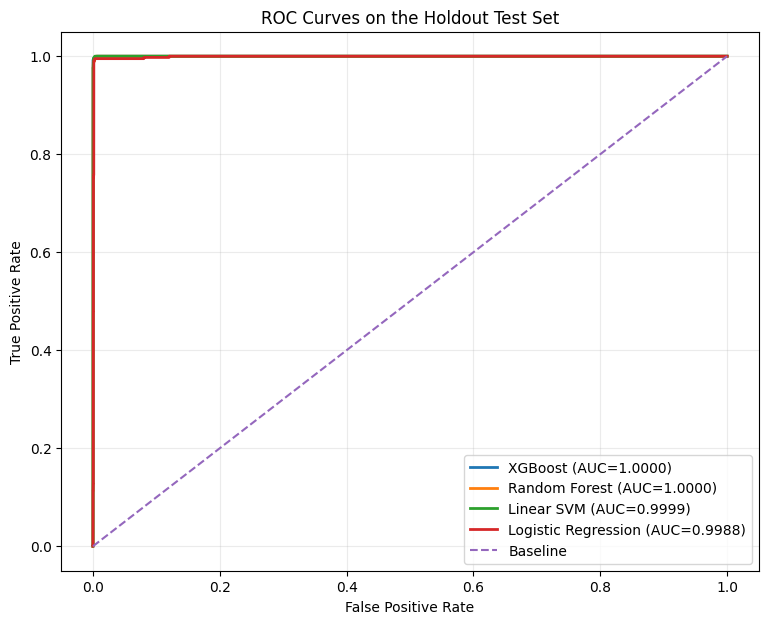

Saved figure: /content/malicious_web_request_final_project/outputs/figures/roc_curve.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# ROC curves
fig, ax = plt.subplots(figsize=(9, 7))
plotted_any = False

for model_name in results_df["model"]:
    score_vector = raw_predictions[model_name]["score_vector"]
    if score_vector is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, score_vector)
    auc_value = roc_auc_score(y_test, score_vector)
    ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc_value:.4f})")
    plotted_any = True

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Baseline")
ax.set_title("ROC Curves on the Holdout Test Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)

if plotted_any:
    plt.show()
    save_current_figure("roc_curve.png")
else:
    print("No ROC-capable models were available.")

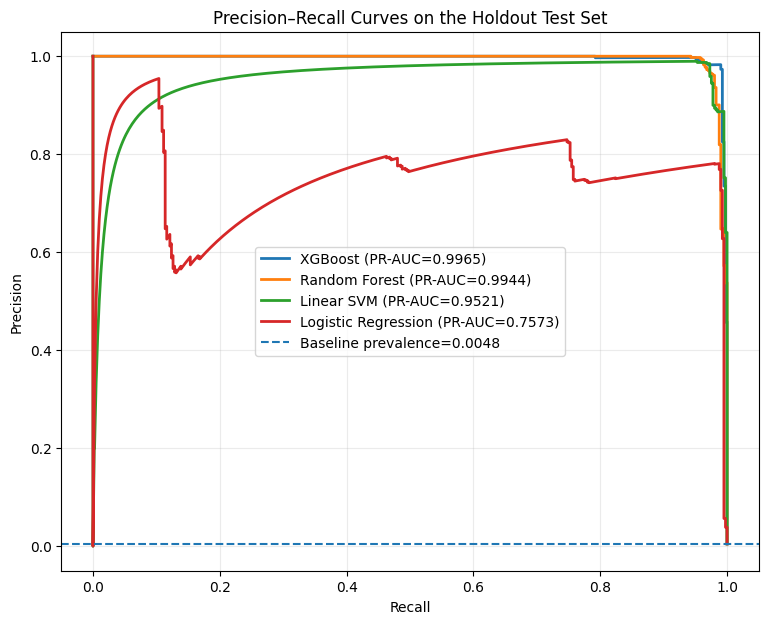

Saved figure: /content/malicious_web_request_final_project/outputs/figures/precision_recall_curve.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(9, 7))
plotted_any = False

for model_name in results_df["model"]:
    score_vector = raw_predictions[model_name]["score_vector"]
    if score_vector is None:
        continue
    prob_like = score_to_probability(score_vector)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob_like)
    pr_auc_value = average_precision_score(y_test, prob_like)
    ax.plot(recall_vals, precision_vals, linewidth=2, label=f"{model_name} (PR-AUC={pr_auc_value:.4f})")
    plotted_any = True

baseline_positive_rate = y_test.mean()
ax.axhline(y=baseline_positive_rate, linestyle="--", linewidth=1.5, label=f"Baseline prevalence={baseline_positive_rate:.4f}")
ax.set_title("Precision–Recall Curves on the Holdout Test Set")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="best")
ax.grid(alpha=0.25)

if plotted_any:
    plt.show()
    save_current_figure("precision_recall_curve.png")
else:
    print("No PR-capable models were available.")

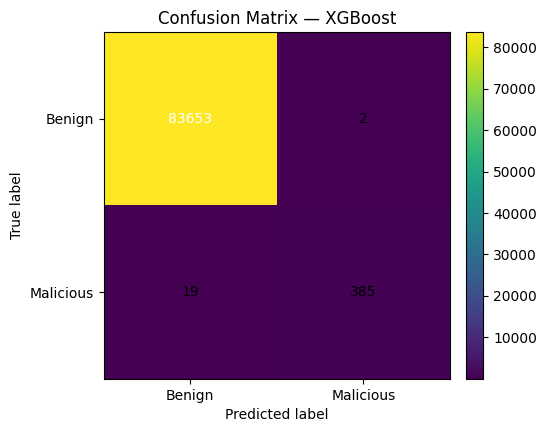

Saved figure: /content/malicious_web_request_final_project/outputs/figures/confusion_matrix_xgboost.png


<Figure size 640x480 with 0 Axes>

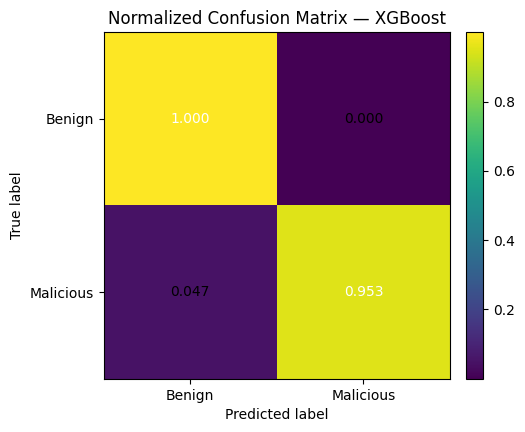

Saved figure: /content/malicious_web_request_final_project/outputs/figures/confusion_matrix_normalized_xgboost.png


<Figure size 640x480 with 0 Axes>

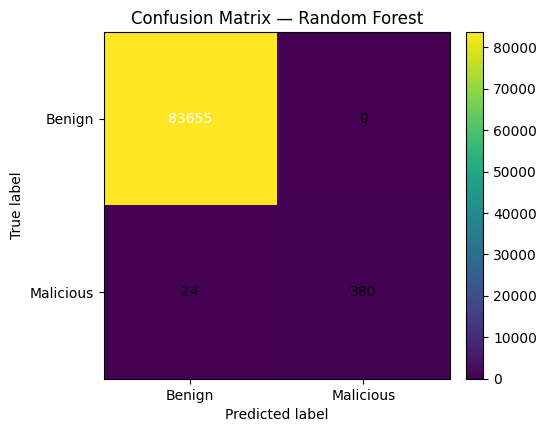

Saved figure: /content/malicious_web_request_final_project/outputs/figures/confusion_matrix_random_forest.png


<Figure size 640x480 with 0 Axes>

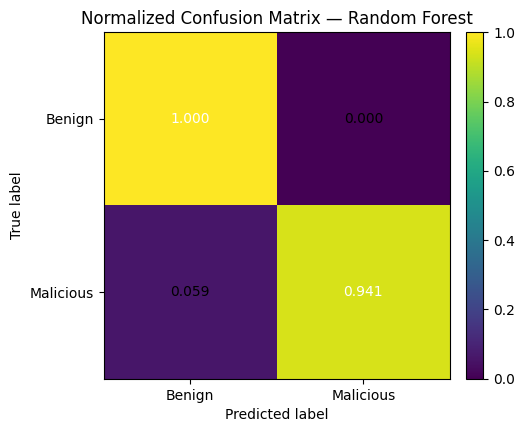

Saved figure: /content/malicious_web_request_final_project/outputs/figures/confusion_matrix_normalized_random_forest.png


<Figure size 640x480 with 0 Axes>

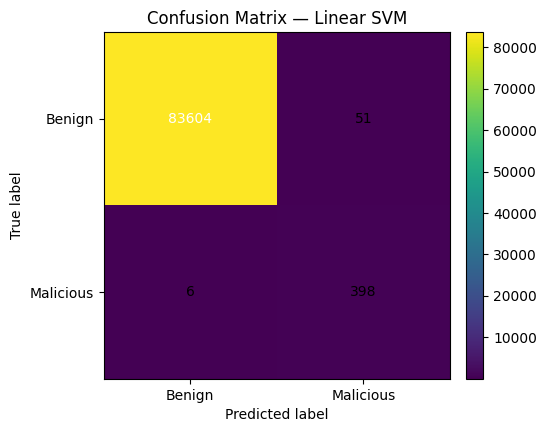

Saved figure: /content/malicious_web_request_final_project/outputs/figures/confusion_matrix_linear_svm.png


<Figure size 640x480 with 0 Axes>

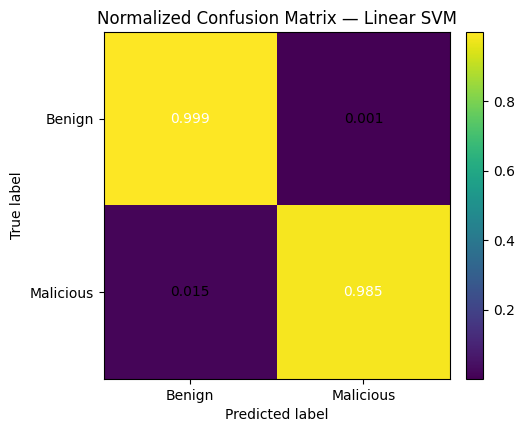

Saved figure: /content/malicious_web_request_final_project/outputs/figures/confusion_matrix_normalized_linear_svm.png


<Figure size 640x480 with 0 Axes>

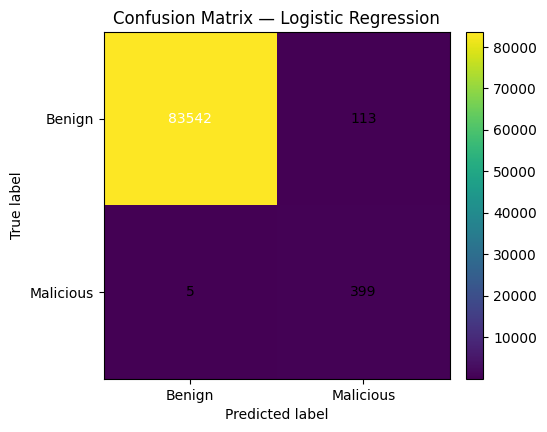

Saved figure: /content/malicious_web_request_final_project/outputs/figures/confusion_matrix_logistic_regression.png


<Figure size 640x480 with 0 Axes>

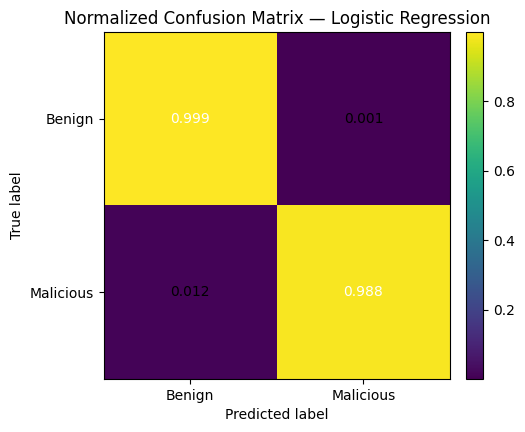

Saved figure: /content/malicious_web_request_final_project/outputs/figures/confusion_matrix_normalized_logistic_regression.png


<Figure size 640x480 with 0 Axes>

In [ ]:
def plot_confusion_heatmap(cm, labels, title):
    fig, ax = plt.subplots(figsize=(5.2, 4.5))
    im = ax.imshow(cm, interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    threshold = cm.max() / 2 if cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_str = f"{value:.3f}" if isinstance(value, float) or isinstance(value, np.floating) else str(value)
            ax.text(j, i, text_str, ha="center", va="center", color="white" if value > threshold else "black")
    plt.show()

for model_name in results_df["model"]:
    cm = confusion_matrices[model_name]
    plot_confusion_heatmap(cm, ["Benign", "Malicious"], f"Confusion Matrix — {model_name}")
    save_current_figure(f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    plot_confusion_heatmap(cm_norm, ["Benign", "Malicious"], f"Normalized Confusion Matrix — {model_name}")
    save_current_figure(f"confusion_matrix_normalized_{model_name.lower().replace(' ', '_')}.png")

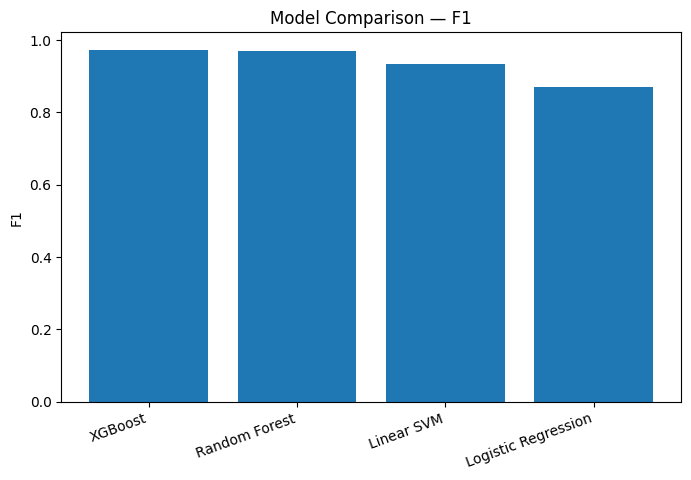

Saved figure: /content/malicious_web_request_final_project/outputs/figures/f1_comparison.png


<Figure size 640x480 with 0 Axes>

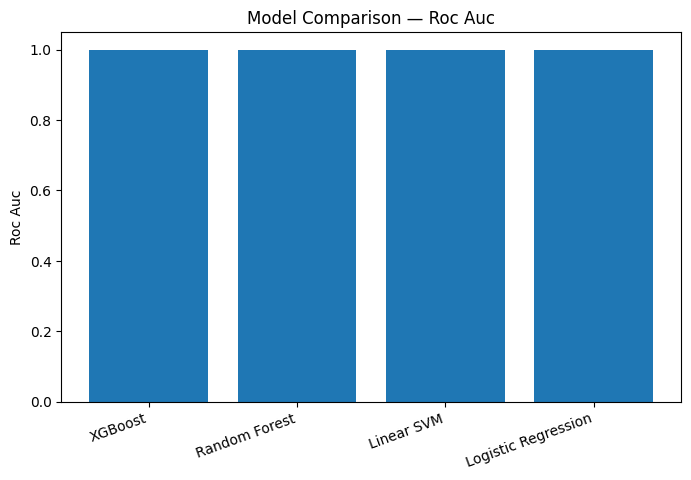

Saved figure: /content/malicious_web_request_final_project/outputs/figures/roc_auc_comparison.png


<Figure size 640x480 with 0 Axes>

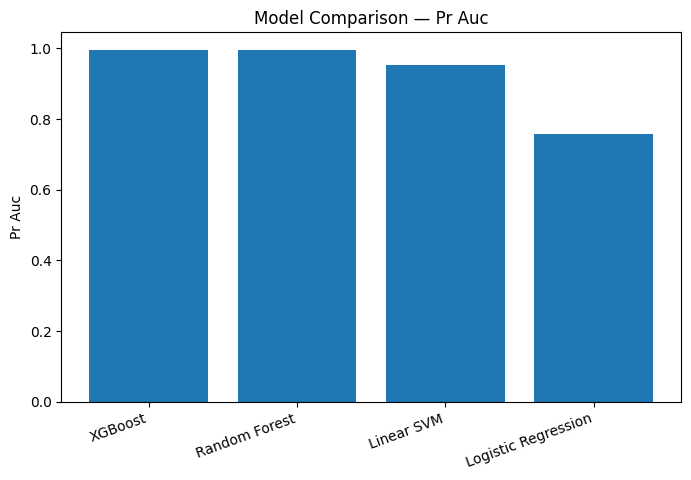

Saved figure: /content/malicious_web_request_final_project/outputs/figures/pr_auc_comparison.png


<Figure size 640x480 with 0 Axes>

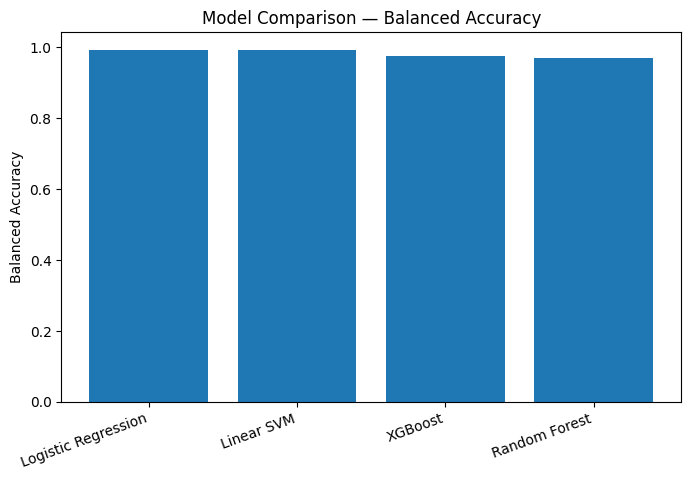

Saved figure: /content/malicious_web_request_final_project/outputs/figures/balanced_accuracy_comparison.png


<Figure size 640x480 with 0 Axes>

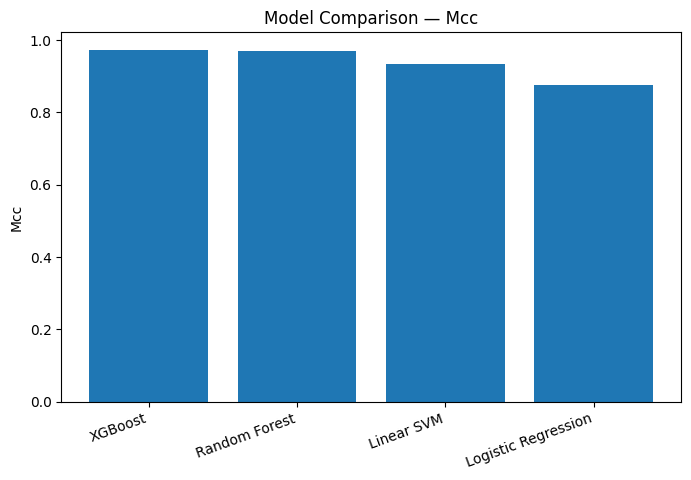

Saved figure: /content/malicious_web_request_final_project/outputs/figures/mcc_comparison.png


<Figure size 640x480 with 0 Axes>

In [ ]:
comparison_metrics = ["f1", "roc_auc", "pr_auc", "balanced_accuracy", "mcc"]

for metric_name in comparison_metrics:
    plot_df = results_df.sort_values(metric_name, ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    ax.bar(plot_df["model"], plot_df[metric_name])
    ax.set_title(f"Model Comparison — {metric_name.replace('_', ' ').title()}")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.set_xticklabels(plot_df["model"], rotation=20, ha="right")
    plt.show()
    save_current_figure(f"{metric_name}_comparison.png")

## Threshold Analysis

The default threshold of **0.5** is not sacred in a security setting.

A lower threshold may reduce missed attacks by increasing recall.  
A higher threshold may reduce false alarms by increasing precision.

The analysis below evaluates multiple thresholds for probability-based models and highlights a practical candidate threshold using the highest F1-score on the holdout test set.

In [ ]:
probability_models = [
    model_name for model_name in results_df["model"]
    if raw_predictions[model_name]["score_vector"] is not None
]

best_threshold_model = None
best_threshold_reference = -np.inf

for model_name in probability_models:
    score_vector = raw_predictions[model_name]["score_vector"]
    if model_artifacts[model_name]["supports_probability"]:
        candidate_value = average_precision_score(y_test, score_to_probability(score_vector))
        if candidate_value > best_threshold_reference:
            best_threshold_reference = candidate_value
            best_threshold_model = model_name

if best_threshold_model is None:
    raise RuntimeError("Threshold analysis could not proceed because no score-producing model was available.")

best_threshold_scores = score_to_probability(raw_predictions[best_threshold_model]["score_vector"])

threshold_rows = []
for thr in np.round(np.arange(0.05, 0.96, 0.05), 2):
    y_thr = (best_threshold_scores >= thr).astype(int)
    metrics_thr = compute_binary_metrics(y_test, y_thr, score_vector=best_threshold_scores)
    threshold_rows.append({
        "model": best_threshold_model,
        "threshold": thr,
        "precision": metrics_thr["precision"],
        "recall": metrics_thr["recall"],
        "f1": metrics_thr["f1"],
        "false_positive_rate": metrics_thr["false_positive_rate"],
        "false_negative_rate": metrics_thr["false_negative_rate"]
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0].to_dict()
selected_threshold = float(best_threshold_row["threshold"])

display(threshold_df.round(4))
threshold_df.round(6).to_csv(TABLE_DIR / "threshold_analysis.csv", index=False)
print("Saved:", TABLE_DIR / "threshold_analysis.csv")
print(f"Threshold analysis model: {best_threshold_model}")
print(f"Selected threshold by holdout F1 ranking: {selected_threshold:.2f}")

,model,threshold,precision,recall,f1,false_positive_rate,false_negative_rate
0,XGBoost,0.05,0.9480,0.9926,0.9698,0.0003,0.0074
1,XGBoost,0.10,0.9780,0.9901,0.9840,0.0001,0.0099
2,XGBoost,0.15,0.9828,0.9901,0.9864,0.0001,0.0099
3,XGBoost,0.20,0.9825,0.9703,0.9763,0.0001,0.0297
4,XGBoost,0.25,0.9849,0.9678,0.9763,0.0001,0.0322
5,XGBoost,0.30,0.9848,0.9653,0.9750,0.0001,0.0347
6,XGBoost,0.35,0.9848,0.9629,0.9737,0.0001,0.0371
7,XGBoost,0.40,0.9898,0.9604,0.9749,0.0000,0.0396
8,XGBoost,0.45,0.9923,0.9554,0.9735,0.0000,0.0446
9,XGBoost,0.50,0.9948,0.9530,0.9735,0.0000,0.0470


Saved: /content/malicious_web_request_final_project/outputs/tables/threshold_analysis.csv
Threshold analysis model: XGBoost
Selected threshold by holdout F1 ranking: 0.15


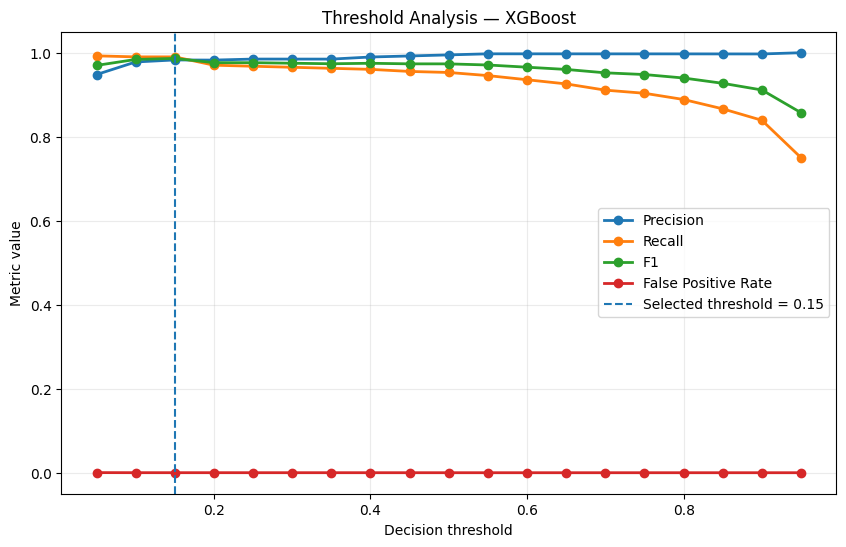

Saved figure: /content/malicious_web_request_final_project/outputs/figures/threshold_analysis_curve.png


PosixPath('/content/malicious_web_request_final_project/outputs/figures/threshold_analysis_curve.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for metric_name in ["precision", "recall", "f1", "false_positive_rate"]:
    ax.plot(threshold_df["threshold"], threshold_df[metric_name], marker="o", linewidth=2, label=metric_name.replace("_", " ").title())

ax.axvline(selected_threshold, linestyle="--", linewidth=1.5, label=f"Selected threshold = {selected_threshold:.2f}")
ax.set_title(f"Threshold Analysis — {best_threshold_model}")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.legend(loc="best")
ax.grid(alpha=0.25)
plt.show()
save_current_figure("threshold_analysis_curve.png")

## Group-Aware Cross-Validation

A single split is useful, but it is not enough. This section evaluates each model with **GroupKFold** using `source_file` as the grouping variable.

This keeps the fold protocol aligned with the leakage-safe philosophy of the notebook.

In [ ]:
def evaluate_model_with_group_cv(model_name, base_pipeline, X_df, y, groups, n_splits=CV_SPLITS):
    gkf = GroupKFold(n_splits=n_splits)
    fold_rows = []

    for fold_idx, (tr_idx, va_idx) in enumerate(gkf.split(X_df, y, groups), start=1):
        X_tr = X_df.iloc[tr_idx].reset_index(drop=True)
        X_va = X_df.iloc[va_idx].reset_index(drop=True)
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        train_groups_fold = set(groups[tr_idx])
        valid_groups_fold = set(groups[va_idx])
        if train_groups_fold.intersection(valid_groups_fold):
            raise RuntimeError(f"Group leakage detected inside CV fold {fold_idx} for {model_name}.")

        pipe = clone(base_pipeline)
        pipe.fit(X_tr, y_tr)

        y_pred = pipe.predict(X_va)
        score_vector = get_score_vector(pipe, X_va)

        row = {"model": model_name, "fold": fold_idx}
        row.update(compute_binary_metrics(y_va, y_pred, score_vector=score_vector))
        fold_rows.append(row)

        del pipe, X_tr, X_va, y_tr, y_va, y_pred, score_vector
        gc.collect()

    return pd.DataFrame(fold_rows)

cv_fold_tables = []
for model_name, spec in model_specs.items():
    print(f"Running group-aware CV for: {model_name}")
    fold_df = evaluate_model_with_group_cv(
        model_name=model_name,
        base_pipeline=spec["pipeline"],
        X_df=df[["raw_request"]],
        y=df["label"].astype(int).values,
        groups=df["source_file"].astype(str).values,
        n_splits=CV_SPLITS
    )
    cv_fold_tables.append(fold_df)
    gc.collect()

cv_results_long_df = pd.concat(cv_fold_tables, axis=0, ignore_index=True)
display(cv_results_long_df.head())

cv_summary_df = cv_results_long_df.groupby("model").agg({
    "accuracy": ["mean", "std"],
    "precision": ["mean", "std"],
    "recall": ["mean", "std"],
    "f1": ["mean", "std"],
    "roc_auc": ["mean", "std"],
    "pr_auc": ["mean", "std"],
    "balanced_accuracy": ["mean", "std"],
    "mcc": ["mean", "std"]
})

cv_summary_flat = cv_summary_df.copy()
cv_summary_flat.columns = [f"{a}_{b}" for a, b in cv_summary_flat.columns]
cv_summary_flat = cv_summary_flat.reset_index()

display(cv_summary_flat.round(4))

cv_results_long_df.round(6).to_csv(TABLE_DIR / "group_cv_fold_metrics.csv", index=False)
cv_summary_flat.round(6).to_csv(TABLE_DIR / "group_cv_summary.csv", index=False)
print("Saved:", TABLE_DIR / "group_cv_fold_metrics.csv")
print("Saved:", TABLE_DIR / "group_cv_summary.csv")

Running group-aware CV for: Logistic Regression
Running group-aware CV for: Random Forest
Running group-aware CV for: XGBoost
Running group-aware CV for: Linear SVM


,model,fold,accuracy,precision,recall,f1,balanced_accuracy,mcc,tp,tn,fp,fn,specificity,false_positive_rate,false_negative_rate,roc_auc,pr_auc
0,Logistic Regression,1,0.998039,0.994704,0.990840,0.992768,0.995005,0.991637,20660,132563,110,191,0.999171,0.000829,0.009160,0.999619,0.991963
1,Logistic Regression,2,0.990406,0.998378,0.822444,0.901911,0.911184,0.901577,6772,145282,11,1462,0.999924,0.000076,0.177556,0.998937,0.997689
2,Logistic Regression,3,0.999961,1.000000,0.994555,0.997270,0.997278,0.997254,1096,152426,0,6,1.000000,0.000000,0.005445,0.999697,0.998159
3,Random Forest,1,0.933828,0.995918,0.514891,0.678828,0.757280,0.689926,10736,132629,44,10115,0.999668,0.000332,0.485109,0.999010,0.992619
4,Random Forest,2,0.972585,0.999752,0.488948,0.656716,0.744471,0.689244,4026,145292,1,4208,0.999993,0.000007,0.511052,0.996100,0.981589


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std
0,Linear SVM,0.9919,0.0128,0.9988,0.0009,0.9350,0.0886,0.9644,0.0487,0.9998,0.0002,0.9987,0.0015,0.9675,0.0444,0.9615,0.0532
1,Logistic Regression,0.9961,0.0051,0.9977,0.0027,0.9359,0.0983,0.9640,0.0538,0.9994,0.0004,0.9959,0.0034,0.9678,0.0491,0.9635,0.0537
2,Random Forest,0.9687,0.0331,0.9970,0.0024,0.6574,0.2695,0.7724,0.1815,0.9984,0.0020,0.9902,0.0077,0.8286,0.1348,0.7869,0.1686
3,XGBoost,0.9689,0.0357,0.9984,0.0010,0.6780,0.2643,0.7890,0.1764,0.9981,0.0021,0.9866,0.0130,0.8390,0.1322,0.8010,0.1666


Saved: /content/malicious_web_request_final_project/outputs/tables/group_cv_fold_metrics.csv
Saved: /content/malicious_web_request_final_project/outputs/tables/group_cv_summary.csv


## Error Analysis

A good academic notebook should not stop at aggregate scores. It should also inspect the mistakes.

The cells below show:
- false positives: benign requests predicted as malicious
- false negatives: malicious requests predicted as benign

This often reveals whether the model is reacting to encoding, punctuation density, payload fragments, or benign-but-suspicious query patterns.

In [ ]:
error_analysis_model = best_model_name
error_scores = raw_predictions[error_analysis_model]["score_vector"]
error_probs = score_to_probability(error_scores) if error_scores is not None else np.full(len(y_test), np.nan)
error_pred = raw_predictions[error_analysis_model]["y_pred"]

error_df = test_df.copy()
error_df["predicted_label"] = error_pred
error_df["score"] = error_scores if error_scores is not None else np.nan
error_df["probability_like"] = error_probs

false_positive_df = error_df[(error_df["label"] == 0) & (error_df["predicted_label"] == 1)].copy()
false_negative_df = error_df[(error_df["label"] == 1) & (error_df["predicted_label"] == 0)].copy()

false_positive_df = false_positive_df.sort_values("probability_like", ascending=False)
false_negative_df = false_negative_df.sort_values("probability_like", ascending=True)

display(false_positive_df.head(10)[["source_file", "attack_family", "raw_request", "probability_like"]])
display(false_negative_df.head(10)[["source_file", "attack_family", "raw_request", "probability_like"]])

false_positive_df.head(25)[["source_file", "attack_family", "raw_request", "probability_like"]].to_csv(TABLE_DIR / "false_positives_examples.csv", index=False)
false_negative_df.head(25)[["source_file", "attack_family", "raw_request", "probability_like"]].to_csv(TABLE_DIR / "false_negatives_examples.csv", index=False)
print("Saved:", TABLE_DIR / "false_positives_examples.csv")
print("Saved:", TABLE_DIR / "false_negatives_examples.csv")

,source_file,attack_family,raw_request,probability_like
63324,Legitimate/browsing_2024_youtube.json,legitimate,/gen_204?oq=friends&gs_l=youtube.3..0i512i433k...,0.935015
20404,Legitimate/browsing_2024_expedia_kayak.json,legitimate,/tr/?id=1347583438592982&ev=Search&ts=17206025...,0.513072


,source_file,attack_family,raw_request,probability_like
83857,Malicious/sqli.json,malicious,/?p=%2Bconcat%280x3c666f6e7420636f6c6f723d7265...,0.003253
83935,Malicious/sqli.json,malicious,/?p=RANDOMBLOB%281000000000/2%29,0.012666
83991,Malicious/sqli.json,malicious,/?p=select%20versionnumber%2C%20version_timest...,0.023381
83843,Malicious/sqli.json,malicious,/?p=AND%20updatexml%28rand%28%29%2Cconcat%280x...,0.077245
83702,Malicious/sqli.json,malicious,/?p=1%20AND%20extractvalue%28rand%28%29%2Cconc...,0.154333
83981,Malicious/sqli.json,malicious,/?p=SELECT%20replace%28replace%28replace%28rep...,0.162845
83840,Malicious/sqli.json,malicious,/?p=AND%20updatexml%28rand%28%29%2Cconcat%280x...,0.172272
83699,Malicious/sqli.json,malicious,/?p=1%20AND%20extractvalue%28rand%28%29%2Cconc...,0.174999
83956,Malicious/sqli.json,malicious,/?p=SELECT%20DBMS_JAVA.RUNJAVA%28%27oracle/aur...,0.184248
84024,Malicious/sqli.json,malicious,/?p=UNION%20SELECT%200x3c3f7068702073797374656...,0.186387


Saved: /content/malicious_web_request_final_project/outputs/tables/false_positives_examples.csv
Saved: /content/malicious_web_request_final_project/outputs/tables/false_negatives_examples.csv


In [ ]:
def summarize_error_patterns(df_subset, top_k=10):
    if len(df_subset) == 0:
        return pd.DataFrame(columns=["pattern", "count"])

    tokens = Counter()
    for txt in df_subset["raw_request"].astype(str):
        lowered = txt.lower()
        for pattern in [
            "%", "../", "select", "union", "script", "cmd", "wget", "curl",
            "http", "https", "=", "&", "?", "0x", "%hex", "passwd", "jndi"
        ]:
            if pattern in lowered:
                tokens[pattern] += 1

    return pd.DataFrame(tokens.most_common(top_k), columns=["pattern", "count"])

print("Potential patterns inside false positives")
display(summarize_error_patterns(false_positive_df))

print("Potential patterns inside false negatives")
display(summarize_error_patterns(false_negative_df))

fp_count = len(false_positive_df)
fn_count = len(false_negative_df)

if fp_count > 0 or fn_count > 0:
    print(
        "Interpretation note: errors may arise from benign requests containing unusual encoding, high punctuation density, "
        "or suspicious substrings, and from malicious requests whose syntax is less explicit or less represented in training data."
    )
else:
    print(
        "No holdout errors were observed for the selected model. This should be discussed carefully rather than celebrated blindly, "
        "because near-perfect performance on security datasets can still indicate residual dataset simplicity or hidden overlap."
    )

Potential patterns inside false positives


,pattern,count
0,=,2
1,&,2
2,?,2
3,%,1


Potential patterns inside false negatives


,pattern,count
0,%,19
1,=,19
2,?,19
3,select,17
4,0x,9
5,union,3
6,cmd,1


Interpretation note: errors may arise from benign requests containing unusual encoding, high punctuation density, or suspicious substrings, and from malicious requests whose syntax is less explicit or less represented in training data.


## Final Model Selection

The best final model is selected using a practical ranking that prioritizes:
1. F1-score
2. PR-AUC
3. MCC
4. ROC-AUC

This reflects a security-oriented preference for balanced usefulness rather than raw accuracy alone.

In [ ]:
results_ranked_df = results_df.sort_values(["f1", "pr_auc", "mcc", "roc_auc"], ascending=False).reset_index(drop=True)
best_model_name = results_ranked_df.iloc[0]["model"]

print("Selected final model:", best_model_name)
display(results_ranked_df.round(4))

best_model_metrics = results_ranked_df.iloc[0].to_dict()

Selected final model: XGBoost


,model,accuracy,precision,recall,f1,balanced_accuracy,mcc,tp,tn,fp,fn,specificity,false_positive_rate,false_negative_rate,roc_auc,pr_auc,inference_seconds_total,inference_ms_per_request,train_seconds,serialized_pipeline_size_mb
0,XGBoost,0.9998,0.9948,0.9530,0.9735,0.9765,0.9736,385,83653,2,19,1.0000,0.0000,0.0470,1.0000,0.9965,27.0955,0.3223,273.0612,0.9505
1,Random Forest,0.9997,1.0000,0.9406,0.9694,0.9703,0.9697,380,83655,0,24,1.0000,0.0000,0.0594,1.0000,0.9944,27.3238,0.3251,354.2943,2.3307
2,Linear SVM,0.9993,0.8864,0.9851,0.9332,0.9923,0.9342,398,83604,51,6,0.9994,0.0006,0.0149,0.9999,0.9521,28.5877,0.3401,252.6000,0.0535
3,Logistic Regression,0.9986,0.7793,0.9876,0.8712,0.9931,0.8767,399,83542,113,5,0.9986,0.0014,0.0124,0.9988,0.7573,28.3686,0.3375,268.5902,0.0536


## Save Artifacts

The final export section writes:
- `best_pipeline.joblib`
- `model_comparison.csv`
- `group_cv_summary.csv`
- `threshold_analysis.csv`
- error analysis CSV files
- exported figure files
- `metadata.json`

The saved pipeline includes:
- text preprocessing
- vectorization
- scaling
- dimensionality reduction if used
- classifier

In [ ]:
best_pipeline_path = MODEL_DIR / "best_pipeline.joblib"
best_pipeline = joblib.load(model_artifacts[best_model_name]["path"])
joblib.dump(best_pipeline, best_pipeline_path, compress=3)

metadata = {
    "project_name": "Malicious Web Request Detection",
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "best_model_name": best_model_name,
    "train_size": int(len(train_df)),
    "test_size": int(len(test_df)),
    "total_rows_after_cleaning": int(len(df)),
    "class_distribution_train": train_df["label"].value_counts().sort_index().to_dict(),
    "class_distribution_test": test_df["label"].value_counts().sort_index().to_dict(),
    "selected_threshold_model": best_threshold_model,
    "selected_threshold": selected_threshold,
    "all_metrics": results_ranked_df.to_dict(orient="records")
}

metadata_path = MODEL_DIR / "metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved:", best_pipeline_path)
print("Saved:", metadata_path)

del best_pipeline
gc.collect()

Saved: /content/malicious_web_request_final_project/outputs/models/best_pipeline.joblib
Saved: /content/malicious_web_request_final_project/outputs/models/metadata.json


55

## Final Conclusion

The next cell generates a concise, automatic conclusion grounded in the notebook outputs rather than hard-coded claims.

In [ ]:
best_row = results_ranked_df.iloc[0].to_dict()

conclusion_lines = []
conclusion_lines.append(f"**Best final model:** {best_model_name}")
conclusion_lines.append(
    f"- Holdout F1-score: **{best_row['f1']:.4f}**"
)
conclusion_lines.append(
    f"- Holdout PR-AUC: **{best_row['pr_auc']:.4f}**"
)
conclusion_lines.append(
    f"- Holdout MCC: **{best_row['mcc']:.4f}**"
)
conclusion_lines.append(
    f"- Balanced Accuracy: **{best_row['balanced_accuracy']:.4f}**"
)

reason = (
    "It was selected because it provided the strongest overall trade-off across F1-score, PR-AUC, and MCC, "
    "which is more credible for a security classification task than relying on accuracy alone."
)
conclusion_lines.append(f"- Selection rationale: {reason}")

limitations = [
    "The dataset may still contain families of requests that are structurally similar even after deduplication.",
    "Group-aware splitting by source file is stronger than a naive random split, but it is still not equivalent to a true out-of-domain production benchmark.",
    "Very high scores should be discussed cautiously, because security datasets can sometimes be easier than real traffic."
]
conclusion_lines.append("**Current limitations**")
for item in limitations:
    conclusion_lines.append(f"- {item}")

future_work = [
    "Evaluate on a more heterogeneous external benchmark or on newer traffic sources.",
    "Add calibrated probability analysis and operating-point selection tied to business cost.",
    "Test temporal splits or source-family holdout protocols when source metadata allows it.",
    "Expand the error analysis with attack-family-level stratification."
]
conclusion_lines.append("**Recommended future improvements**")
for item in future_work:
    conclusion_lines.append(f"- {item}")

display(Markdown("\n".join(conclusion_lines)))

**Best final model:** XGBoost
- Holdout F1-score: **0.9735**
- Holdout PR-AUC: **0.9965**
- Holdout MCC: **0.9736**
- Balanced Accuracy: **0.9765**
- Selection rationale: It was selected because it provided the strongest overall trade-off across F1-score, PR-AUC, and MCC, which is more credible for a security classification task than relying on accuracy alone.
**Current limitations**
- The dataset may still contain families of requests that are structurally similar even after deduplication.
- Group-aware splitting by source file is stronger than a naive random split, but it is still not equivalent to a true out-of-domain production benchmark.
- Very high scores should be discussed cautiously, because security datasets can sometimes be easier than real traffic.
**Recommended future improvements**
- Evaluate on a more heterogeneous external benchmark or on newer traffic sources.
- Add calibrated probability analysis and operating-point selection tied to business cost.
- Test temporal splits or source-family holdout protocols when source metadata allows it.
- Expand the error analysis with attack-family-level stratification.